## MEMBERSHIP AUDIT || How can a business measure the ROI of its loyalty program and evaluate the impact of customer segmentation on its performance?

### LIBRARIES AND DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('supermarket_sales.csv')

### Step 1 || City AND Customer Type

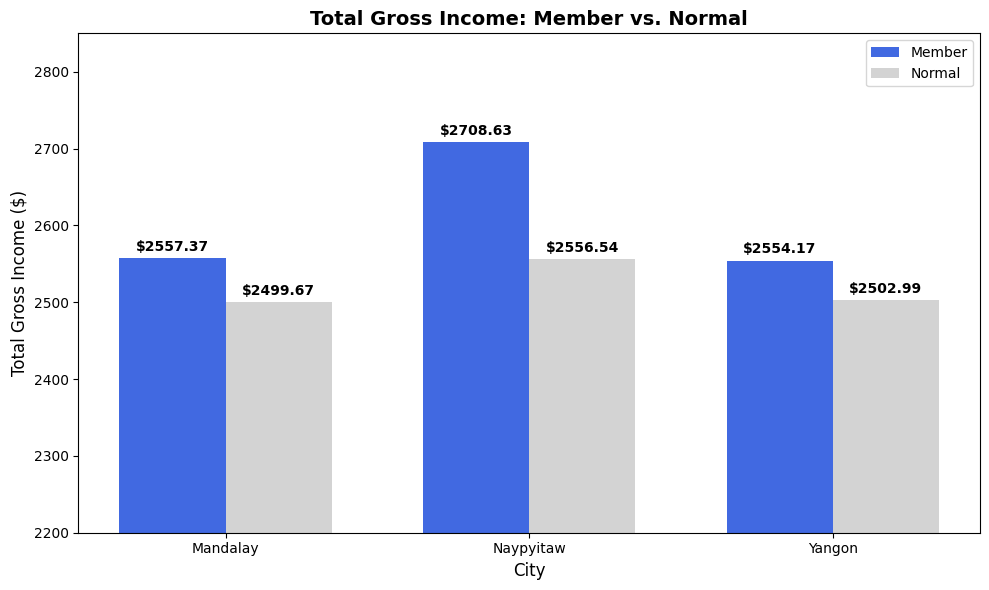

In [2]:
member_value_audit = df.groupby(['City', 'Customer type']).agg({
    'gross income': 'sum'
}).reset_index()

cities = member_value_audit['City'].unique()
x = np.arange(len(cities))  
width = 0.35  

member_data = member_value_audit[member_value_audit['Customer type'] == 'Member']
normal_data = member_value_audit[member_value_audit['Customer type'] == 'Normal']

fig, ax1 = plt.subplots(figsize=(10, 6))

bars1 = ax1.bar(x - width/2, member_data['gross income'], width, label='Member', color='royalblue')
bars2 = ax1.bar(x + width/2, normal_data['gross income'], width, label='Normal', color='lightgrey')

ax1.set_xlabel('City', fontsize=12)
ax1.set_ylabel('Total Gross Income ($)', fontsize=12)
ax1.set_title('Total Gross Income: Member vs. Normal', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(cities)
ax1.bar_label(bars1, padding=3, fmt='$%.2f', fontweight='bold')
ax1.bar_label(bars2, padding=3, fmt='$%.2f', fontweight='bold')
ax1.legend()
ax1.set_ylim(2200, 2850)

plt.tight_layout()

### Step 2 || Average Transaction Size & Average Rating (Member Vs Normal)

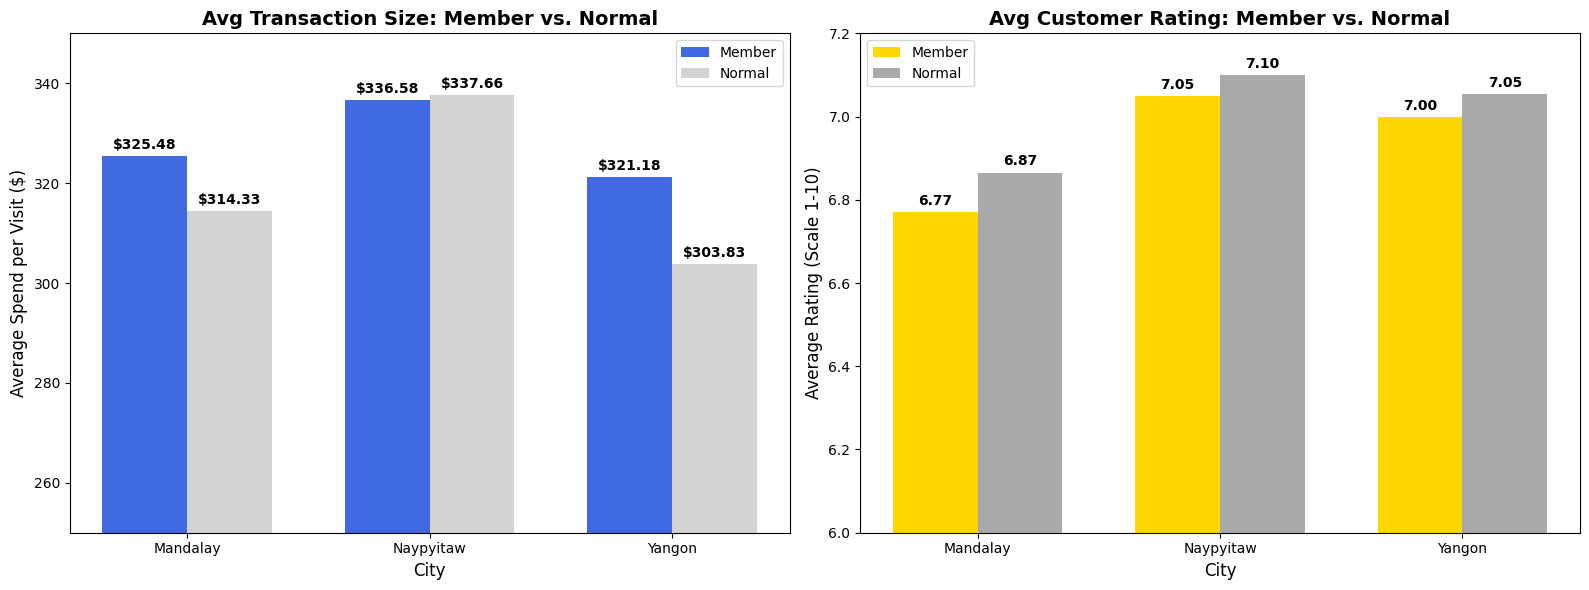

In [3]:
statistical_summary = df.groupby(['City', 'Customer type']).agg({
    'Total': 'mean',
    'Rating': 'mean'
}).reset_index()

statistical_summary.columns = ['City', 'Customer type', 'Avg_Transaction_Total', 'Avg_Rating']


cities = statistical_summary['City'].unique()
x = np.arange(len(cities))  
width = 0.35  

member_stats = statistical_summary[statistical_summary['Customer type'] == 'Member']
normal_stats = statistical_summary[statistical_summary['Customer type'] == 'Normal']


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

bars1 = ax1.bar(x - width/2, member_stats['Avg_Transaction_Total'], width, label='Member', color='royalblue')
bars2 = ax1.bar(x + width/2, normal_stats['Avg_Transaction_Total'], width, label='Normal', color='lightgrey')

ax1.set_xlabel('City', fontsize=12)
ax1.set_ylabel('Average Spend per Visit ($)', fontsize=12)
ax1.set_title('Avg Transaction Size: Member vs. Normal', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(cities)
ax1.bar_label(bars1, padding=3, fmt='$%.2f', fontweight='bold')
ax1.bar_label(bars2, padding=3, fmt='$%.2f', fontweight='bold')
ax1.legend()
ax1.set_ylim(250, 350)   

bars3 = ax2.bar(x - width/2, member_stats['Avg_Rating'], width, label='Member', color='gold')
bars4 = ax2.bar(x + width/2, normal_stats['Avg_Rating'], width, label='Normal', color='darkgray')

ax2.set_xlabel('City', fontsize=12)
ax2.set_ylabel('Average Rating (Scale 1-10)', fontsize=12)
ax2.set_title('Avg Customer Rating: Member vs. Normal', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(cities)
ax2.bar_label(bars3, padding=3, fmt='%.2f', fontweight='bold')
ax2.bar_label(bars4, padding=3, fmt='%.2f', fontweight='bold')
ax2.legend()
ax2.set_ylim(6, 7.2)   

plt.tight_layout()

### Step 3 || WIDE FORMAT RESHAPE (Member Vs Normal)

In [4]:
indexed_audit = member_value_audit.set_index(['City', 'Customer type'])

wide_audit = indexed_audit['gross income'].unstack()

wide_audit.columns = ['Member_Gross_Income', 'Normal_Gross_Income']

wide_audit['Difference'] = wide_audit['Member_Gross_Income'] - wide_audit['Normal_Gross_Income']

print("--- Step 3: Wide Format Reshape (Member vs. Normal) ---")
display(wide_audit)

--- Step 3: Wide Format Reshape (Member vs. Normal) ---


,Member_Gross_Income,Normal_Gross_Income,Difference
City,,,
Mandalay,2557.3660,2499.666,57.7000
Naypyitaw,2708.6325,2556.544,152.0885
Yangon,2554.1655,2502.995,51.1705


### Step 4 || Spending Difference & Rating Difference

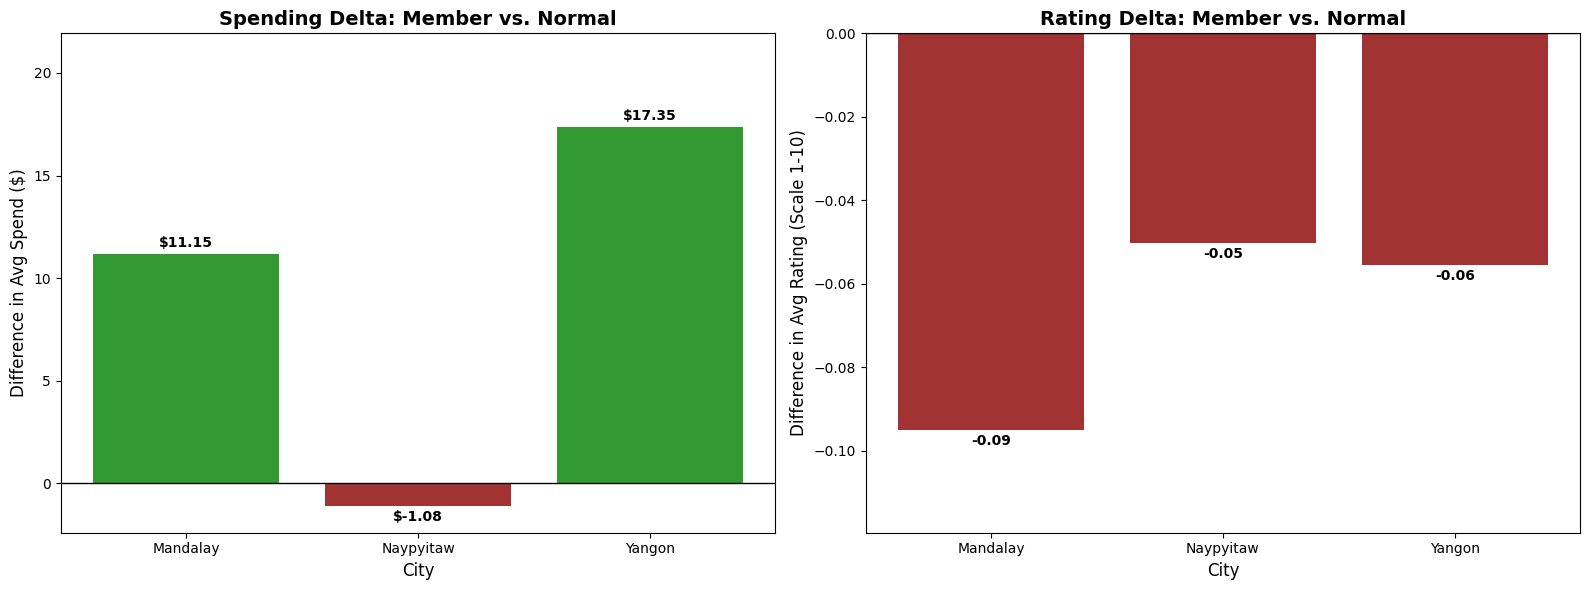

--- Step 4: Member Value Audit (Delta Analysis Table) ---


,Spend_Delta,Rating_Delta
City,,
Mandalay,11.153688,-0.094966
Naypyitaw,-1.081119,-0.050221
Yangon,17.350725,-0.055533


In [5]:
wide_metrics = df.groupby(['City', 'Customer type']).agg({
    'Total': 'mean',
    'Rating': 'mean'
}).unstack()

wide_metrics.columns = [f'{col}_{group}' for col, group in wide_metrics.columns]

wide_metrics['Spend_Delta'] = wide_metrics['Total_Member'] - wide_metrics['Total_Normal']
wide_metrics['Rating_Delta'] = wide_metrics['Rating_Member'] - wide_metrics['Rating_Normal']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors_spend = ['green' if x > 0 else 'darkred' for x in wide_metrics['Spend_Delta']]
bars1 = ax1.bar(wide_metrics.index, wide_metrics['Spend_Delta'], color=colors_spend, alpha=0.8)
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title('Spending Delta: Member vs. Normal', fontsize=14, fontweight='bold')
ax1.set_ylabel('Difference in Avg Spend ($)', fontsize=12)
ax1.bar_label(bars1, padding=3, fmt='$%.2f', fontweight='bold')


colors_rate = ['gold' if x > 0 else 'darkred' for x in wide_metrics['Rating_Delta']]
bars2 = ax2.bar(wide_metrics.index, wide_metrics['Rating_Delta'], color=colors_rate, alpha=0.8)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Rating Delta: Member vs. Normal', fontsize=14, fontweight='bold')
ax2.set_ylabel('Difference in Avg Rating (Scale 1-10)', fontsize=12)
ax2.bar_label(bars2, padding=3, fmt='%.2f', fontweight='bold')


for ax in [ax1, ax2]:
    ax.set_xlabel('City', fontsize=12)
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0] * 1.2, ylim[1] * 1.2)

plt.tight_layout()
plt.show()

print("--- Step 4: Member Value Audit (Delta Analysis Table) ---")
display(wide_metrics[['Spend_Delta', 'Rating_Delta']])

### Step 5 || Are members consistently outspending non-members across all locations?

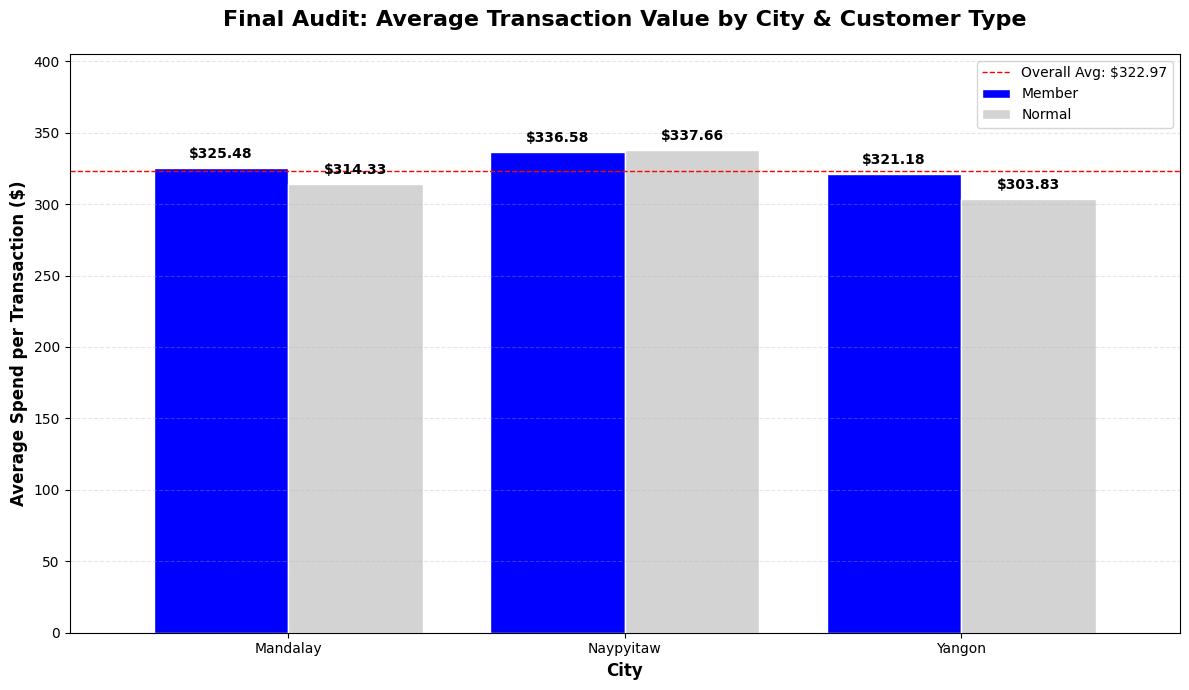

In [ ]:
plot_data = df.groupby(['City', 'Customer type'])['Total'].mean().unstack()

ax = plot_data.plot(kind='bar', 
                    figsize=(12, 7), 
                    width=0.8, 
                    color=['Blue', 'LightGrey'],
                    edgecolor='white')

plt.title('Final Audit: Average Transaction Value by City & Customer Type', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('City', fontsize=12, fontweight='bold')
plt.ylabel('Average Spend per Transaction ($)', fontsize=12, fontweight='bold')
plt.xticks(rotation=0) 
plt.legend(title='Customer Segment', frameon=True, shadow=True)

for container in ax.containers:
    ax.bar_label(container, padding=5, fmt='$%.2f', fontweight='bold', fontsize=10)

overall_avg = df['Total'].mean()
plt.axhline(overall_avg, color='red', linestyle='--', linewidth=1, label=f'Overall Avg: ${overall_avg:.2f}')
plt.legend(loc='upper right')

plt.ylim(0, plot_data.values.max() * 1.2)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()